<a href="https://colab.research.google.com/github/compsm2023/Palo-Alto-Networks-attrition-dashboard/blob/main/Employee_Attrition_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔵 Machine Learning–Based Employee Attrition Prediction & Risk Scoring System
### Palo Alto Networks — HR Analytics Internship Project

---
**Objective:** Predict which employees are at risk of leaving the organization and assign each a risk score (Low / Medium / High) with explainable reasons.

**Dataset:** 1,470 employee records | 31 features | Binary target: `Attrition` (1 = Left, 0 = Stayed)

---
## 📋 Table of Contents
1. Install & Import Libraries
2. Load Dataset
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing
5. Feature Engineering
6. Model Development
7. Model Evaluation
8. Risk Scoring Framework
9. Model Explainability (Feature Importance + SHAP)
10. Export Results

## 📦 CELL 1 — Install & Import Libraries

In [1]:
# Install required libraries (run once)
!pip install shap xgboost imbalanced-learn openpyxl --quiet

# ── Core ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ──────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# ── Preprocessing ──────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# ── Models ─────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# ── Evaluation ─────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)

# ── Explainability ─────────────────────────────────────
import shap

print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


## 📂 CELL 2 — Load Dataset

In [2]:
# ── Upload your file in Colab ──────────────────────────
from google.colab import files

print('📤 Please upload your Palo_Alto_Networks.xlsx file:')
uploaded = files.upload()

import io
filename = list(uploaded.keys())[0]
df = pd.read_excel(io.BytesIO(uploaded[filename]), sheet_name='Palo Alto Networks')

print(f'\n✅ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'\n📊 Target Distribution:')
print(df['Attrition'].value_counts().rename({0: 'Stayed (0)', 1: 'Left (1)'}))
print(f'\nAttrition Rate: {df["Attrition"].mean()*100:.1f}%')

📤 Please upload your Palo_Alto_Networks.xlsx file:


Saving Palo Alto Networks.xlsx to Palo Alto Networks.xlsx

✅ Dataset loaded: 1470 rows × 31 columns

📊 Target Distribution:
Attrition
Stayed (0)    1233
Left (1)       237
Name: count, dtype: int64

Attrition Rate: 16.1%


In [3]:
# ── Quick overview ──────────────────────────────────────
print('=== First 5 rows ===')
display(df.head())

print('\n=== Data Types & Missing Values ===')
info_df = pd.DataFrame({
    'Dtype': df.dtypes,
    'Non-Null': df.notnull().sum(),
    'Null': df.isnull().sum(),
    'Unique': df.nunique()
})
display(info_df)

print('\n=== Statistical Summary ===')
display(df.describe().round(2))

=== First 5 rows ===


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2



=== Data Types & Missing Values ===


,Dtype,Non-Null,Null,Unique
Age,int64,1470,0,43
Attrition,int64,1470,0,2
BusinessTravel,object,1470,0,3
DailyRate,int64,1470,0,886
Department,object,1470,0,3
DistanceFromHome,int64,1470,0,29
Education,int64,1470,0,5
EducationField,object,1470,0,6
EnvironmentSatisfaction,int64,1470,0,4
Gender,object,1470,0,2



=== Statistical Summary ===


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,...,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,36.92,0.16,802.49,9.19,2.91,2.72,65.89,2.73,2.06,2.73,...,3.15,2.71,0.79,11.28,2.80,2.76,7.01,4.23,2.19,4.12
std,9.14,0.37,403.51,8.11,1.02,1.09,20.33,0.71,1.11,1.10,...,0.36,1.08,0.85,7.78,1.29,0.71,6.13,3.62,3.22,3.57
min,18.00,0.00,102.00,1.00,1.00,1.00,30.00,1.00,1.00,1.00,...,3.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
25%,30.00,0.00,465.00,2.00,2.00,2.00,48.00,2.00,1.00,2.00,...,3.00,2.00,0.00,6.00,2.00,2.00,3.00,2.00,0.00,2.00
50%,36.00,0.00,802.00,7.00,3.00,3.00,66.00,3.00,2.00,3.00,...,3.00,3.00,1.00,10.00,3.00,3.00,5.00,3.00,1.00,3.00
75%,43.00,0.00,1157.00,14.00,4.00,4.00,83.75,3.00,3.00,4.00,...,3.00,4.00,1.00,15.00,3.00,3.00,9.00,7.00,3.00,7.00
max,60.00,1.00,1499.00,29.00,5.00,4.00,100.00,4.00,5.00,4.00,...,4.00,4.00,3.00,40.00,6.00,4.00,40.00,18.00,15.00,17.00


## 🔍 CELL 3 — Exploratory Data Analysis (EDA)

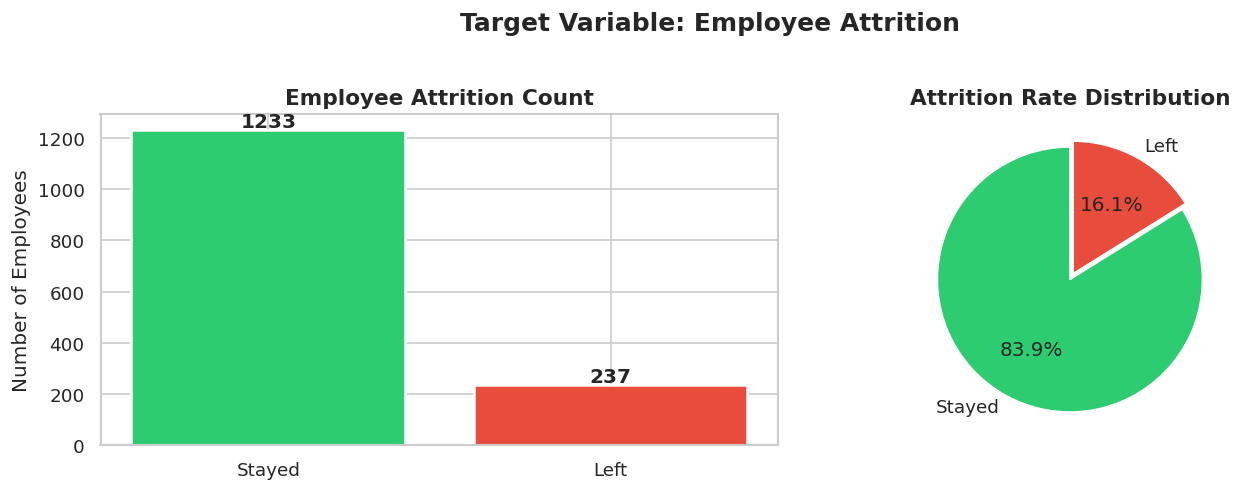

⚠️  Class Imbalance detected — we will apply SMOTE to fix this later.


In [4]:
# ── 3.1 Target Distribution ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#2ecc71', '#e74c3c']
counts = df['Attrition'].value_counts()
axes[0].bar(['Stayed', 'Left'], counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Employee Attrition Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Employees')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Stayed', 'Left'], colors=colors,
            autopct='%1.1f%%', startangle=90, explode=[0, 0.05])
axes[1].set_title('Attrition Rate Distribution', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: Employee Attrition', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('⚠️  Class Imbalance detected — we will apply SMOTE to fix this later.')

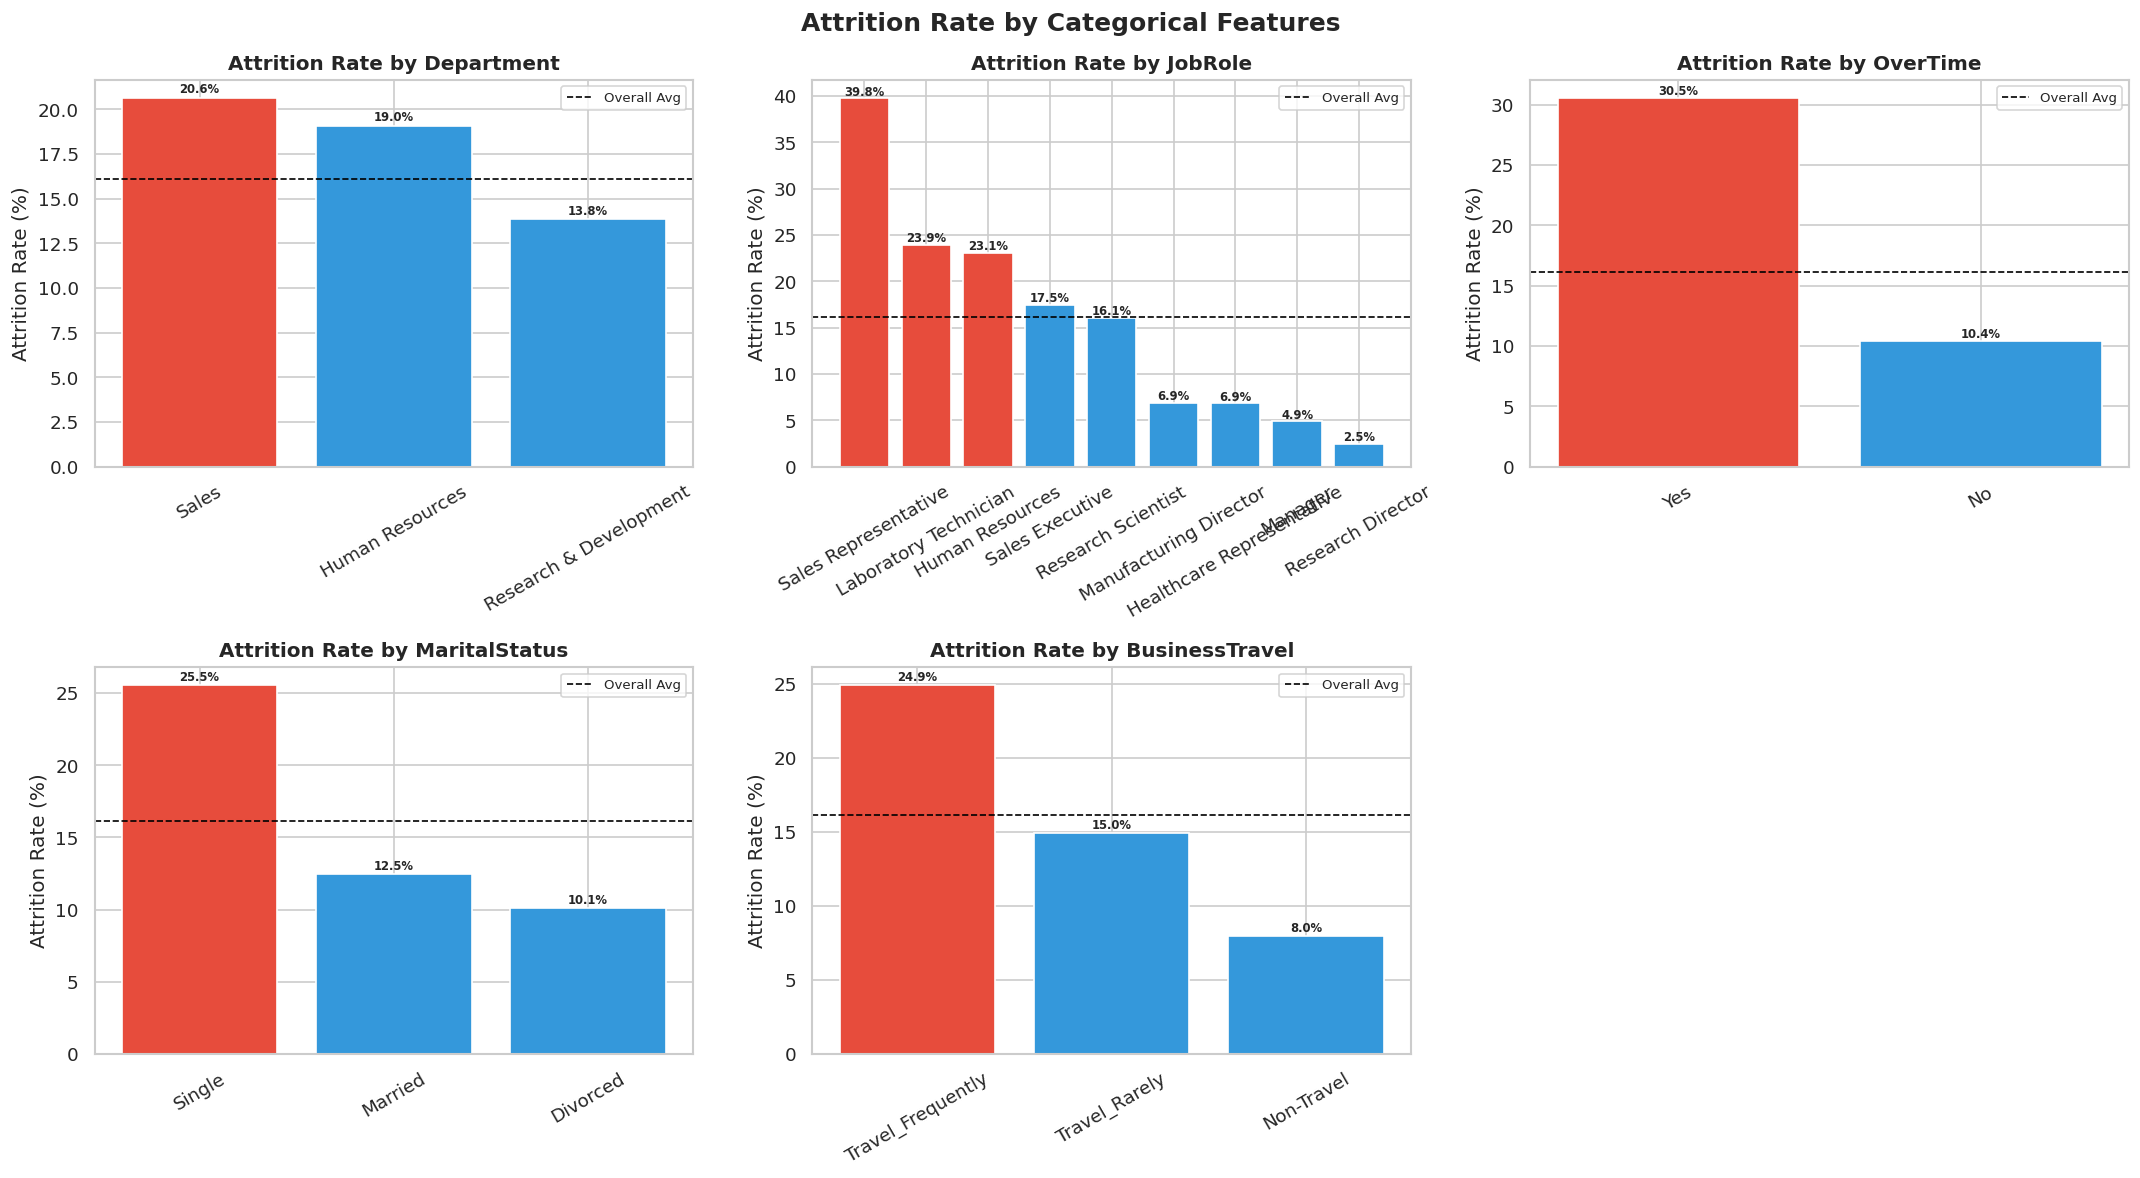

In [5]:
# ── 3.2 Attrition by Key Categorical Features ──────────
cat_features = ['Department', 'JobRole', 'OverTime', 'MaritalStatus', 'BusinessTravel']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    ct = df.groupby(col)['Attrition'].mean().sort_values(ascending=False) * 100
    bars = axes[i].bar(ct.index, ct.values,
                       color=['#e74c3c' if v > 20 else '#3498db' for v in ct.values],
                       edgecolor='white')
    axes[i].set_title(f'Attrition Rate by {col}', fontweight='bold')
    axes[i].set_ylabel('Attrition Rate (%)')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].axhline(df['Attrition'].mean()*100, color='black', linestyle='--',
                    linewidth=1, label='Overall Avg')
    axes[i].legend(fontsize=8)
    for bar, val in zip(bars, ct.values):
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                     f'{val:.1f}%', ha='center', fontsize=7, fontweight='bold')

axes[-1].axis('off')
plt.suptitle('Attrition Rate by Categorical Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

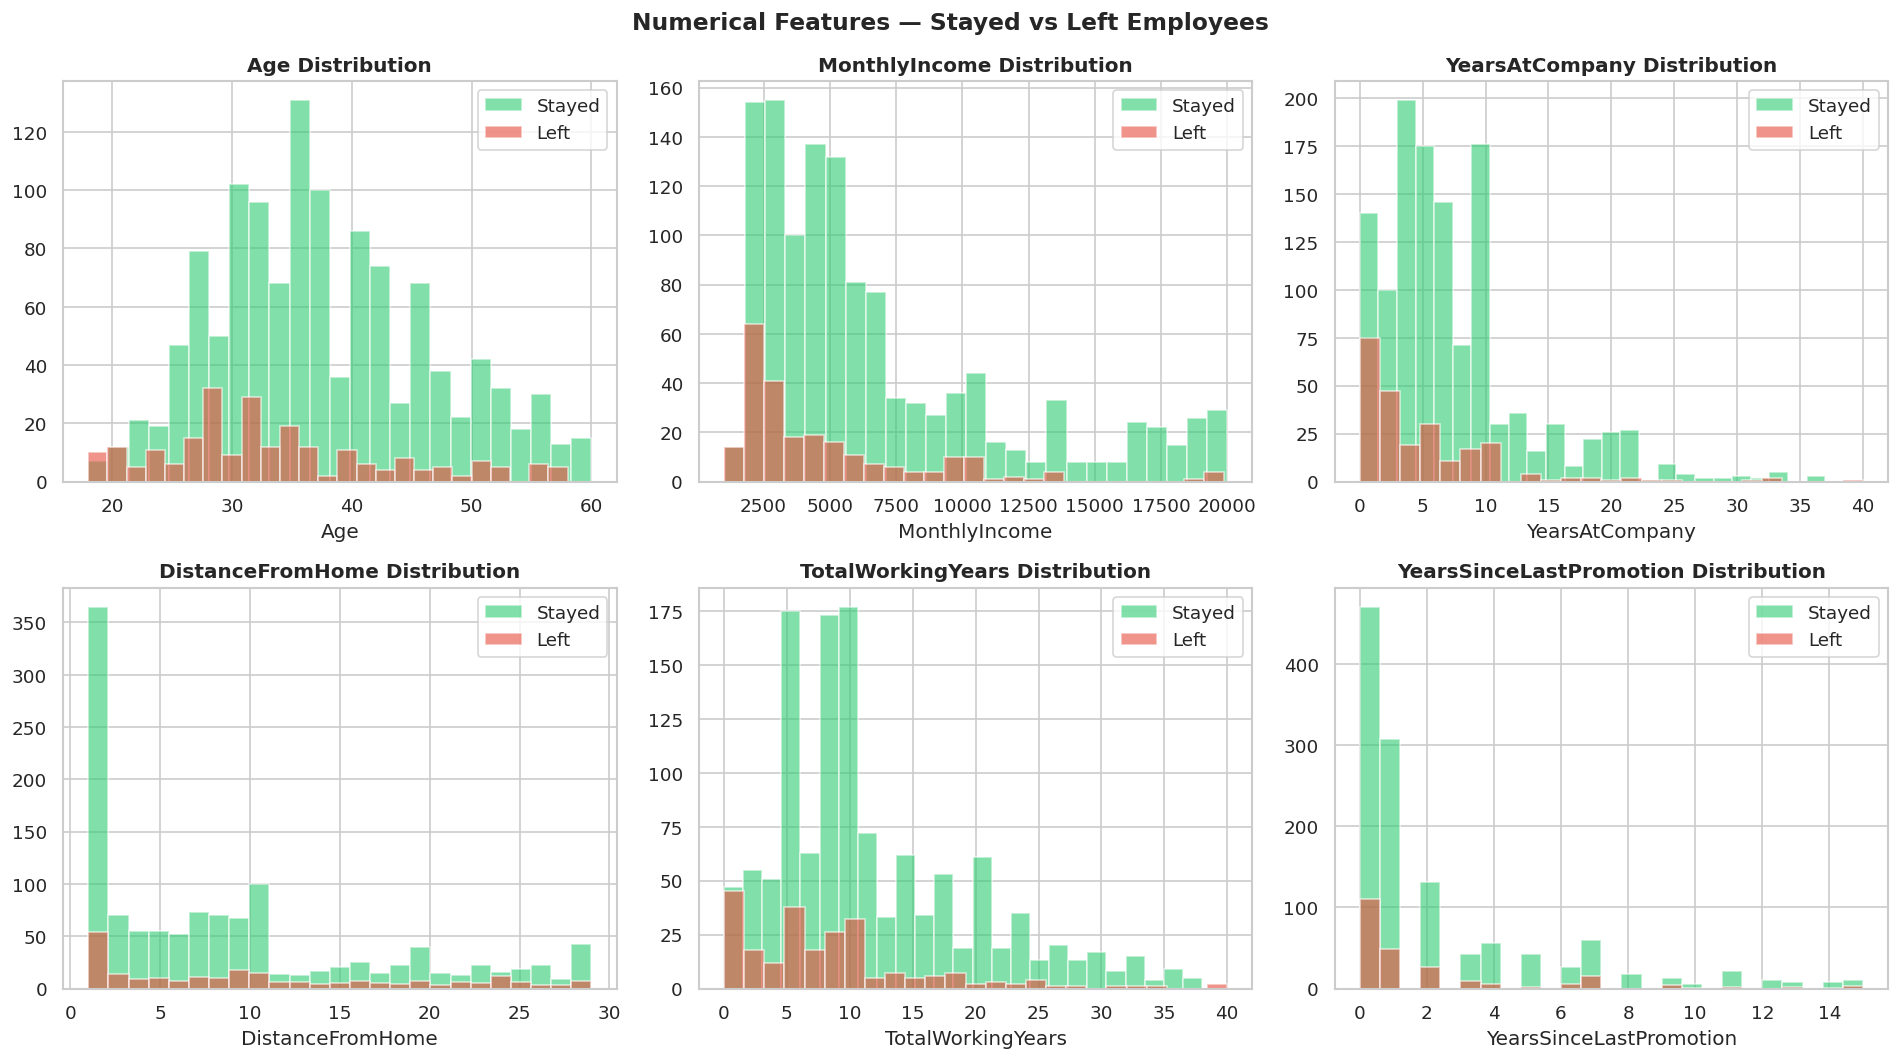

In [6]:
# ── 3.3 Numerical Feature Distributions by Attrition ───
num_features = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'DistanceFromHome',
                'TotalWorkingYears', 'YearsSinceLastPromotion']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
palette = {0: '#2ecc71', 1: '#e74c3c'}

for i, col in enumerate(num_features):
    for val, color in palette.items():
        subset = df[df['Attrition'] == val][col]
        axes[i].hist(subset, bins=25, alpha=0.6, color=color,
                     label='Stayed' if val==0 else 'Left', edgecolor='white')
    axes[i].set_title(f'{col} Distribution', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].legend()

plt.suptitle('Numerical Features — Stayed vs Left Employees', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

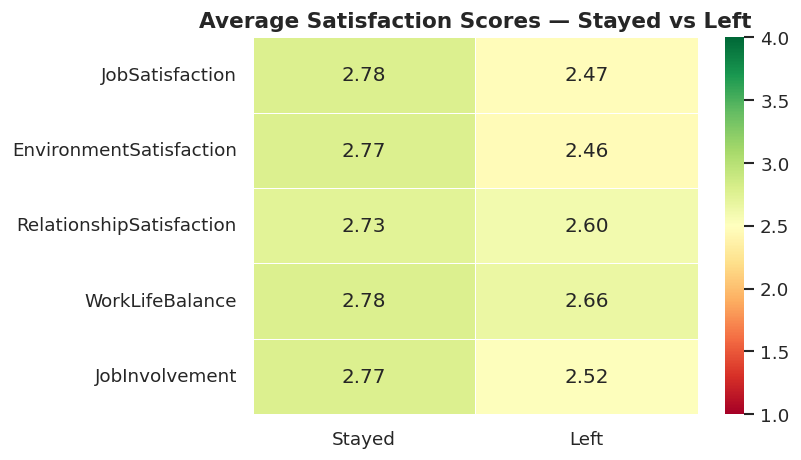

💡 Lower scores across all satisfaction metrics → higher attrition risk


In [7]:
# ── 3.4 Satisfaction Scores Heatmap ────────────────────
satisfaction_cols = ['JobSatisfaction', 'EnvironmentSatisfaction',
                     'RelationshipSatisfaction', 'WorkLifeBalance', 'JobInvolvement']

sat_attrition = df.groupby('Attrition')[satisfaction_cols].mean().T
sat_attrition.columns = ['Stayed', 'Left']

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(sat_attrition, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, vmin=1, vmax=4)
ax.set_title('Average Satisfaction Scores — Stayed vs Left', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('💡 Lower scores across all satisfaction metrics → higher attrition risk')

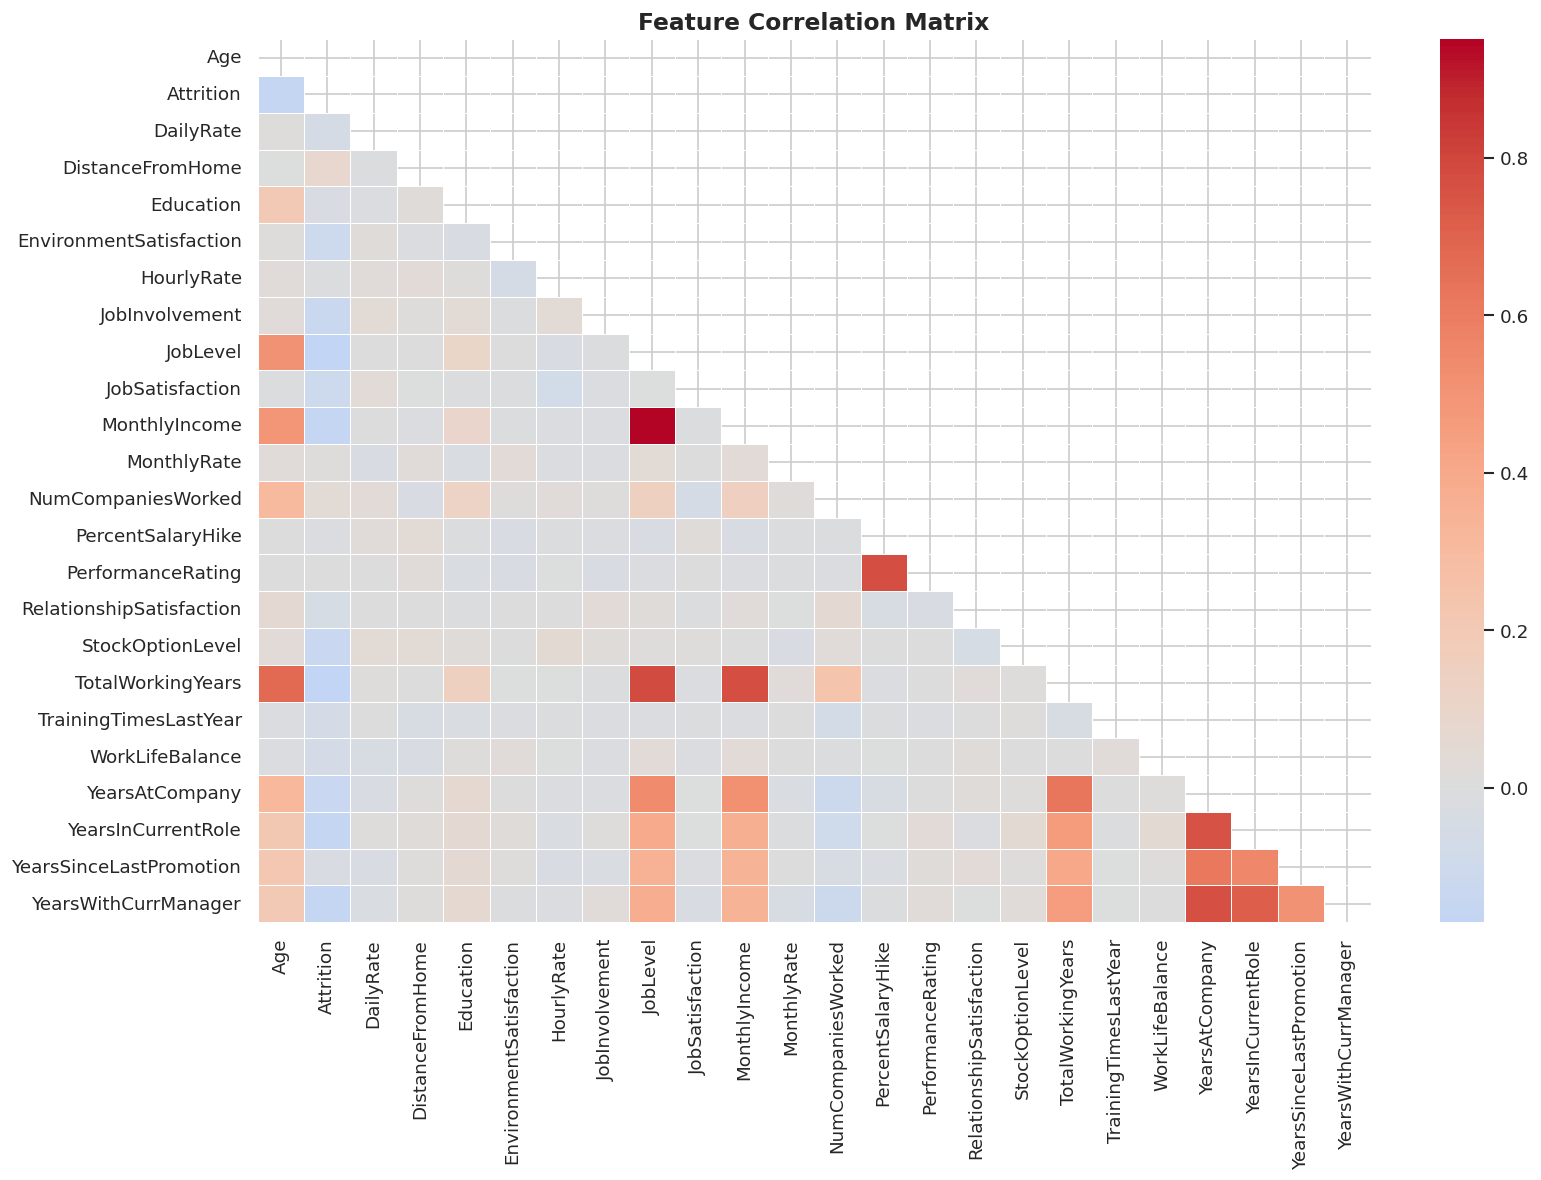


🎯 Top features correlated with Attrition:
TotalWorkingYears       0.171063
JobLevel                0.169105
YearsInCurrentRole      0.160545
MonthlyIncome           0.159840
Age                     0.159205
YearsWithCurrManager    0.156199
StockOptionLevel        0.137145
YearsAtCompany          0.134392
JobInvolvement          0.130016
JobSatisfaction         0.103481


In [8]:
# ── 3.5 Correlation Heatmap ────────────────────────────
plt.figure(figsize=(14, 10))
num_df = df.select_dtypes(include=np.number)
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            annot=False, linewidths=0.4, fmt='.1f')
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations with Attrition
print('\n🎯 Top features correlated with Attrition:')
attrition_corr = corr['Attrition'].drop('Attrition').abs().sort_values(ascending=False)
print(attrition_corr.head(10).to_string())

## ⚙️ CELL 4 — Data Preprocessing

In [9]:
# ── 4.1 Encode Categorical Variables ──────────────────
df_processed = df.copy()

# Binary encoding
binary_map = {'Yes': 1, 'No': 0}
df_processed['OverTime'] = df_processed['OverTime'].map(binary_map)

# Ordinal encoding
travel_map = {'Non-Travel': 0, 'Travel_Rarely': 1, 'Travel_Frequently': 2}
df_processed['BusinessTravel'] = df_processed['BusinessTravel'].map(travel_map)

gender_map = {'Male': 1, 'Female': 0}
df_processed['Gender'] = df_processed['Gender'].map(gender_map)

marital_map = {'Single': 0, 'Married': 1, 'Divorced': 2}
df_processed['MaritalStatus'] = df_processed['MaritalStatus'].map(marital_map)

# One-Hot Encoding for high-cardinality categoricals
ohe_cols = ['Department', 'EducationField', 'JobRole']
df_processed = pd.get_dummies(df_processed, columns=ohe_cols, drop_first=True)

print(f'✅ Encoding complete. Shape: {df_processed.shape}')
print(f'\nSample of boolean columns converted to int:')
bool_cols = df_processed.select_dtypes(include='bool').columns.tolist()
if bool_cols:
    df_processed[bool_cols] = df_processed[bool_cols].astype(int)
print(df_processed.dtypes.value_counts())

✅ Encoding complete. Shape: (1470, 43)

Sample of boolean columns converted to int:
int64    43
Name: count, dtype: int64


In [10]:
# ── 4.2 Train-Test Split ───────────────────────────────
X = df_processed.drop('Attrition', axis=1)
y = df_processed['Attrition'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size : {X_train.shape[0]} samples')
print(f'Test size  : {X_test.shape[0]} samples')
print(f'\nTrain Attrition Rate: {y_train.mean()*100:.1f}%')
print(f'Test  Attrition Rate: {y_test.mean()*100:.1f}%')

Train size : 1176 samples
Test size  : 294 samples

Train Attrition Rate: 16.2%
Test  Attrition Rate: 16.0%


In [11]:
# ── 4.3 Handle Class Imbalance with SMOTE ─────────────
print('Before SMOTE:', pd.Series(y_train).value_counts().to_dict())

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('After SMOTE :', pd.Series(y_train_sm).value_counts().to_dict())

# ── 4.4 Feature Scaling ────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled  = scaler.transform(X_test)

print('\n✅ SMOTE applied + Features scaled!')

Before SMOTE: {0: 986, 1: 190}
After SMOTE : {0: 986, 1: 986}

✅ SMOTE applied + Features scaled!


## 🔧 CELL 5 — Feature Engineering

In [12]:
# ── Add engineered features to original df ────────────
# We'll add these before the train-test split for final model

df_fe = df.copy()

# 1. Income-to-Experience Ratio — underpaid relative to experience?
df_fe['Income_Experience_Ratio'] = df_fe['MonthlyIncome'] / (df_fe['TotalWorkingYears'] + 1)

# 2. Promotion Delay — years since last promo vs years in role
df_fe['Promotion_Delay'] = df_fe['YearsSinceLastPromotion'] - df_fe['YearsInCurrentRole']

# 3. Engagement Composite Score (average of all satisfaction metrics)
df_fe['Engagement_Score'] = df_fe[[
    'JobSatisfaction', 'EnvironmentSatisfaction',
    'RelationshipSatisfaction', 'WorkLifeBalance', 'JobInvolvement'
]].mean(axis=1)

# 4. Workload Stress Flag — overtime + low work-life balance
df_fe['OverTime_bin'] = (df_fe['OverTime'] == 'Yes').astype(int)
df_fe['Workload_Stress'] = df_fe['OverTime_bin'] * (5 - df_fe['WorkLifeBalance'])

# 5. Loyalty Score — years at company relative to total experience
df_fe['Loyalty_Score'] = df_fe['YearsAtCompany'] / (df_fe['TotalWorkingYears'] + 1)

# Show how features correlate with attrition
new_features = ['Income_Experience_Ratio', 'Promotion_Delay',
                'Engagement_Score', 'Workload_Stress', 'Loyalty_Score']

print('📊 Engineered Feature Correlations with Attrition:')
for f in new_features:
    corr_val = df_fe[f].corr(df_fe['Attrition'])
    direction = '🔴 Risk' if corr_val > 0 else '🟢 Protective'
    print(f'  {f:<30} r = {corr_val:+.3f}  {direction}')

📊 Engineered Feature Correlations with Attrition:
  Income_Experience_Ratio        r = +0.098  🔴 Risk
  Promotion_Delay                r = +0.145  🔴 Risk
  Engagement_Score               r = -0.193  🟢 Protective
  Workload_Stress                r = +0.242  🔴 Risk
  Loyalty_Score                  r = -0.092  🟢 Protective


## 🤖 CELL 6 — Model Development

In [13]:
# ── 6.1 Define All Models ──────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest':        RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced'),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42),
    'XGBoost':              XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=4,
                                          use_label_encoder=False, eval_metric='logloss',
                                          scale_pos_weight=5, random_state=42, verbosity=0)
}

# ── 6.2 Train All Models ───────────────────────────────
results = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train_sm)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    results[name] = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1-Score':  f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_prob)
    }
    trained_models[name] = (model, y_pred, y_prob)
    print(f'✅ {name} trained.')

print('\n🎯 All models trained!')

✅ Logistic Regression trained.
✅ Random Forest trained.
✅ Gradient Boosting trained.
✅ XGBoost trained.

🎯 All models trained!


## 📊 CELL 7 — Model Evaluation

In [14]:
# ── 7.1 Metrics Comparison Table ──────────────────────
results_df = pd.DataFrame(results).T.sort_values('ROC-AUC', ascending=False)
results_df = results_df.round(4)

print('='*65)
print('MODEL PERFORMANCE COMPARISON')
print('='*65)
display(results_df.style
        .background_gradient(cmap='YlGn', subset=['ROC-AUC', 'F1-Score', 'Recall'])
        .format('{:.4f}'))

best_model_name = results_df.index[0]
print(f'\n🏆 Best Model: {best_model_name} (ROC-AUC = {results_df.loc[best_model_name, "ROC-AUC"]:.4f})')

MODEL PERFORMANCE COMPARISON


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.8401,0.5000,0.4468,0.4719,0.7725
Random Forest,0.8401,0.5000,0.3191,0.3896,0.7586
Gradient Boosting,0.8503,0.5484,0.3617,0.4359,0.7482
XGBoost,0.7721,0.3387,0.4468,0.3853,0.7287



🏆 Best Model: Logistic Regression (ROC-AUC = 0.7725)


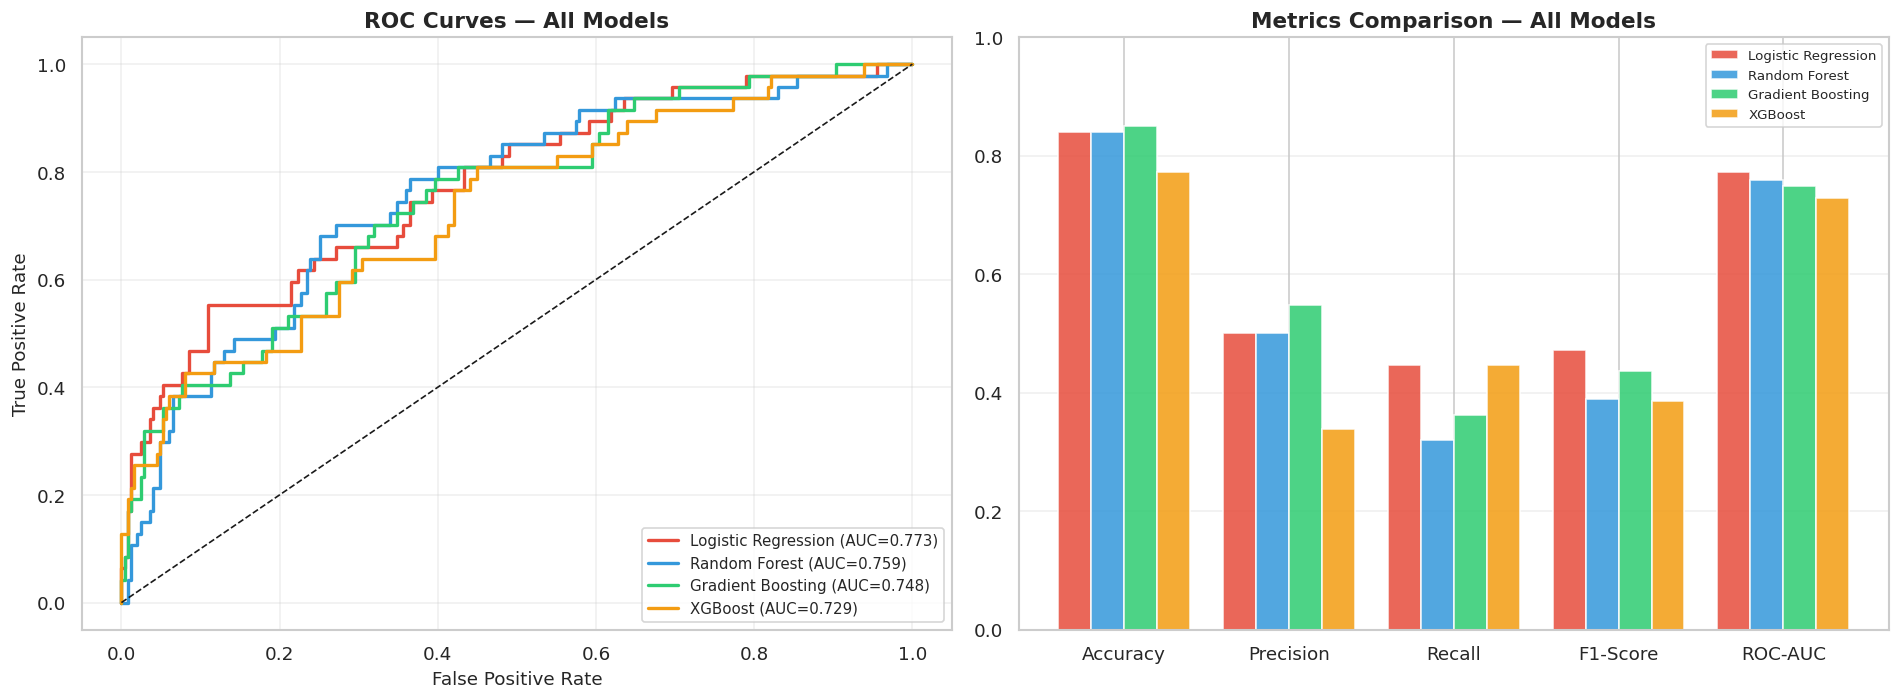

In [15]:
# ── 7.2 ROC Curves for All Models ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors_map = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for (name, (model, y_pred, y_prob)), color in zip(trained_models.items(), colors_map):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)

axes[0].plot([0,1],[0,1], 'k--', linewidth=1)
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(True, alpha=0.3)

# Bar chart comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.2
for i, (name, color) in enumerate(zip(results.keys(), colors_map)):
    vals = [results[name][m] for m in metrics]
    axes[1].bar(x + i*width, vals, width, label=name, color=color, alpha=0.85)

axes[1].set_xticks(x + width*1.5)
axes[1].set_xticklabels(metrics)
axes[1].set_ylim(0, 1)
axes[1].set_title('Metrics Comparison — All Models', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

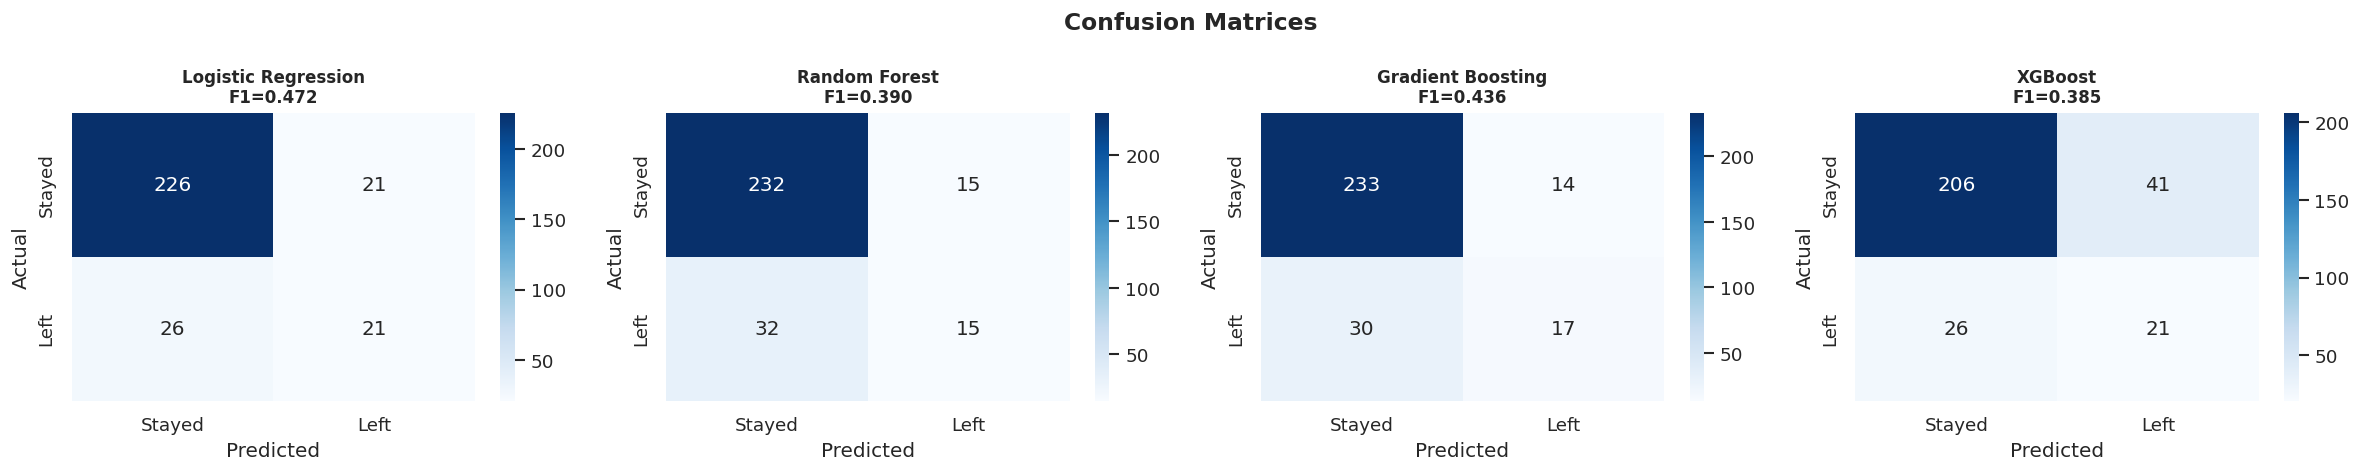

In [16]:
# ── 7.3 Confusion Matrices for All Models ─────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, (model, y_pred, y_prob)) in zip(axes, trained_models.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Stayed', 'Left'], yticklabels=['Stayed', 'Left'])
    ax.set_title(f'{name}\nF1={results[name]["F1-Score"]:.3f}', fontweight='bold', fontsize=10)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
# ── 7.4 Classification Report for Best Model ──────────
best_model, best_y_pred, best_y_prob = trained_models[best_model_name]

print(f'📋 Full Classification Report — {best_model_name}')
print('='*55)
print(classification_report(y_test, best_y_pred, target_names=['Stayed', 'Left']))

📋 Full Classification Report — Logistic Regression
              precision    recall  f1-score   support

      Stayed       0.90      0.91      0.91       247
        Left       0.50      0.45      0.47        47

    accuracy                           0.84       294
   macro avg       0.70      0.68      0.69       294
weighted avg       0.83      0.84      0.84       294



## 🎯 CELL 8 — Risk Scoring Framework

In [19]:
# ── 8.1 Assign Risk Categories to ALL Employees ───────
# Use best model on entire dataset
X_all_scaled = scaler.transform(X)  # scale all records
all_probs = best_model.predict_proba(X_all_scaled)[:, 1]

def get_risk_category(prob):
    if prob < 0.30:   return '🟢 Low Risk'
    elif prob < 0.60: return '🟡 Medium Risk'
    else:             return '🔴 High Risk'

# Build risk score dataframe
risk_df = df[['Department', 'JobRole', 'MonthlyIncome', 'YearsAtCompany',
              'OverTime', 'JobSatisfaction', 'Attrition']].copy()
risk_df['Employee_ID']        = [f'EMP_{str(i+1001).zfill(4)}' for i in range(len(df))]
risk_df['Attrition_Prob']     = (all_probs * 100).round(1)
risk_df['Risk_Category']      = [get_risk_category(p) for p in all_probs]
risk_df['Actual_Left']        = risk_df['Attrition'].map({1:'Yes', 0:'No'})
risk_df = risk_df.drop('Attrition', axis=1)

print('Risk Score Distribution:')
print(risk_df['Risk_Category'].value_counts())
print(f'\n📊 Sample High-Risk Employees:')
display(risk_df[risk_df['Risk_Category']=='🔴 High Risk'].head(10))

Risk Score Distribution:
Risk_Category
🟢 Low Risk       1112
🟡 Medium Risk     211
🔴 High Risk       147
Name: count, dtype: int64

📊 Sample High-Risk Employees:


,Department,JobRole,MonthlyIncome,YearsAtCompany,OverTime,JobSatisfaction,Employee_ID,Attrition_Prob,Risk_Category,Actual_Left
0,Sales,Sales Executive,5993,6,Yes,4,EMP_1001,91.8,🔴 High Risk,Yes
4,Research & Development,Laboratory Technician,3468,2,No,2,EMP_1005,63.1,🔴 High Risk,No
14,Research & Development,Laboratory Technician,2028,4,Yes,3,EMP_1015,93.3,🔴 High Risk,Yes
21,Sales,Sales Representative,3407,5,No,1,EMP_1022,61.0,🔴 High Risk,Yes
26,Research & Development,Research Scientist,3919,10,Yes,1,EMP_1027,92.5,🔴 High Risk,Yes
36,Sales,Sales Representative,2683,3,Yes,3,EMP_1037,74.3,🔴 High Risk,Yes
42,Research & Development,Laboratory Technician,2293,1,No,3,EMP_1043,96.1,🔴 High Risk,Yes
50,Research & Development,Laboratory Technician,5381,1,Yes,3,EMP_1051,73.0,🔴 High Risk,Yes
51,Research & Development,Laboratory Technician,3441,2,Yes,3,EMP_1052,73.9,🔴 High Risk,Yes
54,Sales,Sales Executive,4157,2,Yes,4,EMP_1055,81.2,🔴 High Risk,No


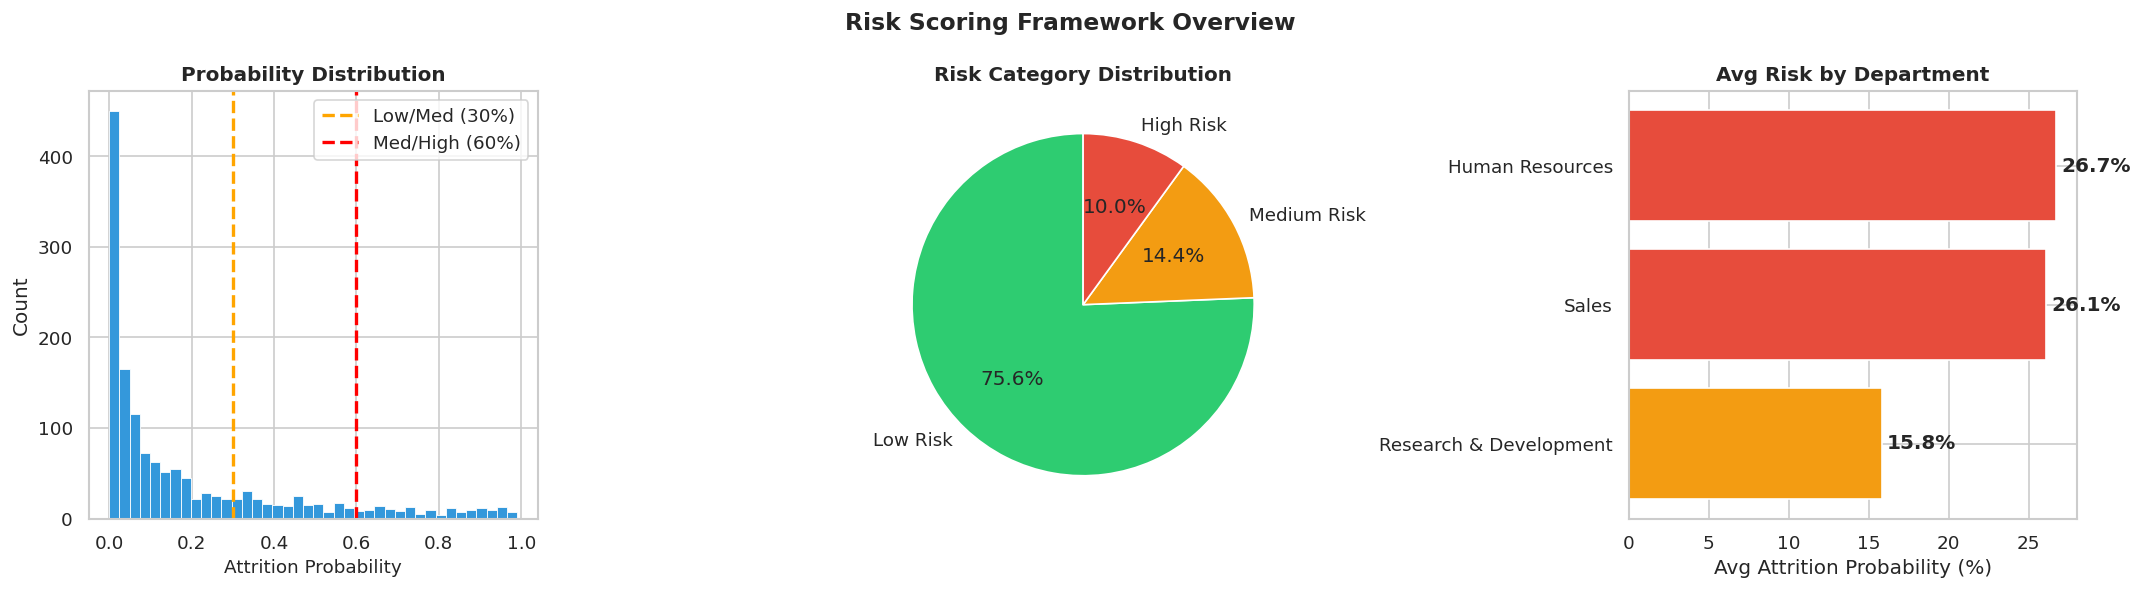

In [20]:
# ── 8.2 Risk Distribution Visualization ───────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram of probabilities
axes[0].hist(all_probs, bins=40, color='#3498db', edgecolor='white', linewidth=0.5)
axes[0].axvline(0.30, color='orange', linestyle='--', linewidth=2, label='Low/Med (30%)')
axes[0].axvline(0.60, color='red',    linestyle='--', linewidth=2, label='Med/High (60%)')
axes[0].set_xlabel('Attrition Probability', fontsize=11)
axes[0].set_ylabel('Count')
axes[0].set_title('Probability Distribution', fontsize=12, fontweight='bold')
axes[0].legend()

# Pie chart of risk categories
cat_counts = risk_df['Risk_Category'].value_counts()
colors_risk = {'🟢 Low Risk': '#2ecc71', '🟡 Medium Risk': '#f39c12', '🔴 High Risk': '#e74c3c'}
pie_colors = [colors_risk[c] for c in cat_counts.index]
axes[1].pie(cat_counts.values, labels=[c.split(' ', 1)[1] for c in cat_counts.index],
            colors=pie_colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Risk Category Distribution', fontsize=12, fontweight='bold')

# Risk by Department
dept_risk = risk_df.groupby('Department')['Attrition_Prob'].mean().sort_values()
bar_colors = ['#e74c3c' if v > 25 else '#f39c12' if v > 15 else '#2ecc71' for v in dept_risk.values]
axes[2].barh(dept_risk.index, dept_risk.values, color=bar_colors, edgecolor='white')
axes[2].set_xlabel('Avg Attrition Probability (%)')
axes[2].set_title('Avg Risk by Department', fontsize=12, fontweight='bold')
for i, v in enumerate(dept_risk.values):
    axes[2].text(v+0.3, i, f'{v:.1f}%', va='center', fontweight='bold')

plt.suptitle('Risk Scoring Framework Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
# ── 8.3 High-Risk Employee Lookup Tool ────────────────
def get_employee_risk_profile(employee_index):
    """
    Displays the risk profile of a single employee.
    Pass 0-based index (row number in original dataframe).
    """
    emp = df.iloc[employee_index]
    prob = all_probs[employee_index]
    risk = get_risk_category(prob)

    print('='*55)
    print(f'  EMPLOYEE RISK PROFILE')
    print('='*55)
    print(f'  Employee Index   : {employee_index}')
    print(f'  Department       : {emp["Department"]}')
    print(f'  Job Role         : {emp["JobRole"]}')
    print(f'  Age              : {int(emp["Age"])} years')
    print(f'  Monthly Income   : ${int(emp["MonthlyIncome"]):,}')
    print(f'  Overtime         : {emp["OverTime"]}')
    print(f'  Job Satisfaction : {int(emp["JobSatisfaction"])}/4')
    print(f'  Years at Company : {int(emp["YearsAtCompany"])}')
    print(f'  Since Promotion  : {int(emp["YearsSinceLastPromotion"])} years')
    print('-'*55)
    print(f'  ⚠️  Attrition Probability: {prob*100:.1f}%')
    print(f'  🚦 Risk Category        : {risk}')
    print(f'  📌 Actual Outcome       : {"Left" if emp["Attrition"]==1 else "Stayed"}')
    print('='*55)

# Try a few examples
get_employee_risk_profile(0)   # First employee
# Try a high risk one
high_risk_idx = np.argmax(all_probs)
get_employee_risk_profile(high_risk_idx)

  EMPLOYEE RISK PROFILE
  Employee Index   : 0
  Department       : Sales
  Job Role         : Sales Executive
  Age              : 41 years
  Monthly Income   : $5,993
  Overtime         : Yes
  Job Satisfaction : 4/4
  Years at Company : 6
  Since Promotion  : 0 years
-------------------------------------------------------
  ⚠️  Attrition Probability: 91.8%
  🚦 Risk Category        : 🔴 High Risk
  📌 Actual Outcome       : Left
  EMPLOYEE RISK PROFILE
  Employee Index   : 463
  Department       : Research & Development
  Job Role         : Laboratory Technician
  Age              : 26 years
  Monthly Income   : $2,340
  Overtime         : Yes
  Job Satisfaction : 4/4
  Years at Company : 1
  Since Promotion  : 0 years
-------------------------------------------------------
  ⚠️  Attrition Probability: 99.0%
  🚦 Risk Category        : 🔴 High Risk
  📌 Actual Outcome       : Left


## 🔍 CELL 9 — Model Explainability

In [22]:
# ── 9.1 Feature Importance (Tree-Based Models) ─────────
if hasattr(best_model, 'feature_importances_'):
    feature_names = X.columns.tolist()
    importance_df = pd.DataFrame({
        'Feature':    feature_names,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False).head(20)

    plt.figure(figsize=(10, 7))
    colors = ['#e74c3c' if i < 5 else '#3498db' if i < 10 else '#95a5a6'
              for i in range(len(importance_df))]
    plt.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1],
             color=colors[::-1], edgecolor='white')
    plt.xlabel('Feature Importance Score', fontsize=11)
    plt.title(f'Top 20 Feature Importances — {best_model_name}', fontsize=13, fontweight='bold')
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

    print('\n🔑 Top 10 Most Important Features:')
    print(importance_df[['Feature','Importance']].head(10).to_string(index=False))

Computing SHAP values (this may take ~30 seconds)...


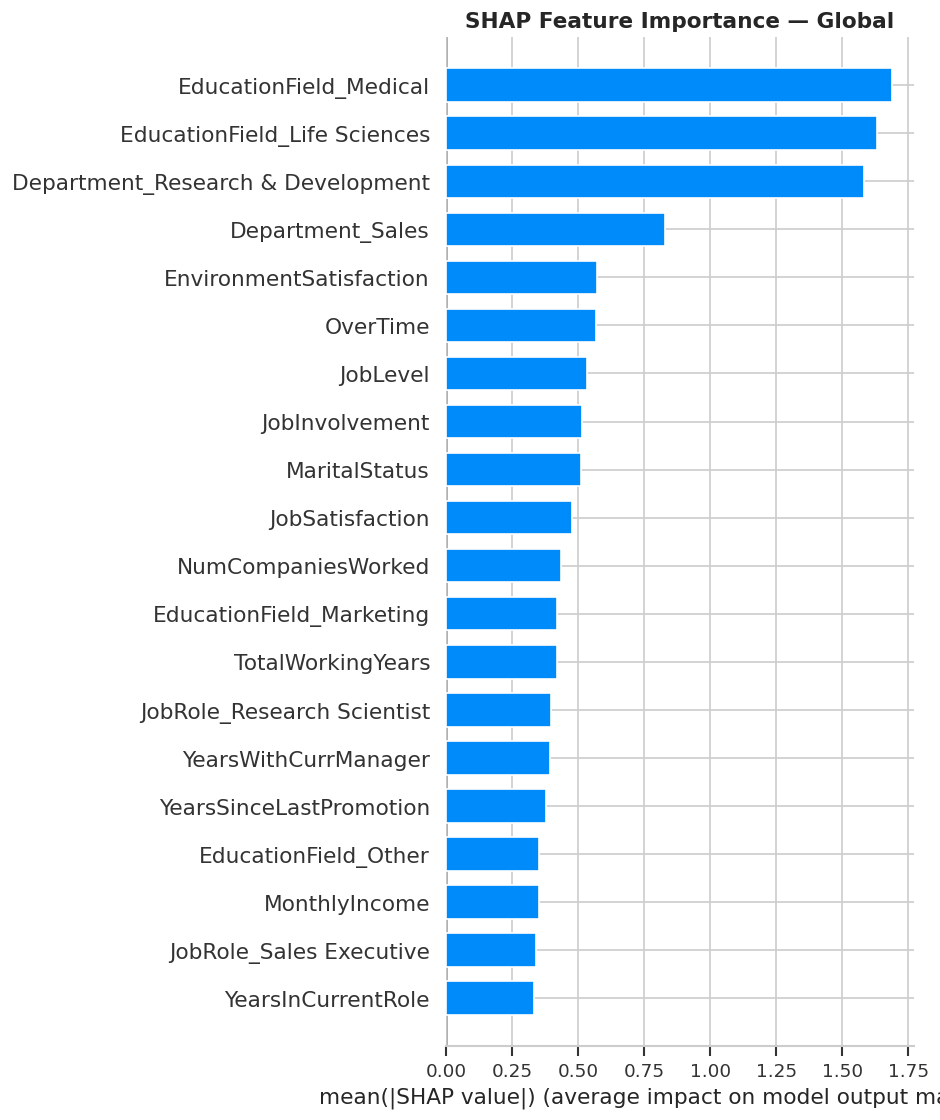

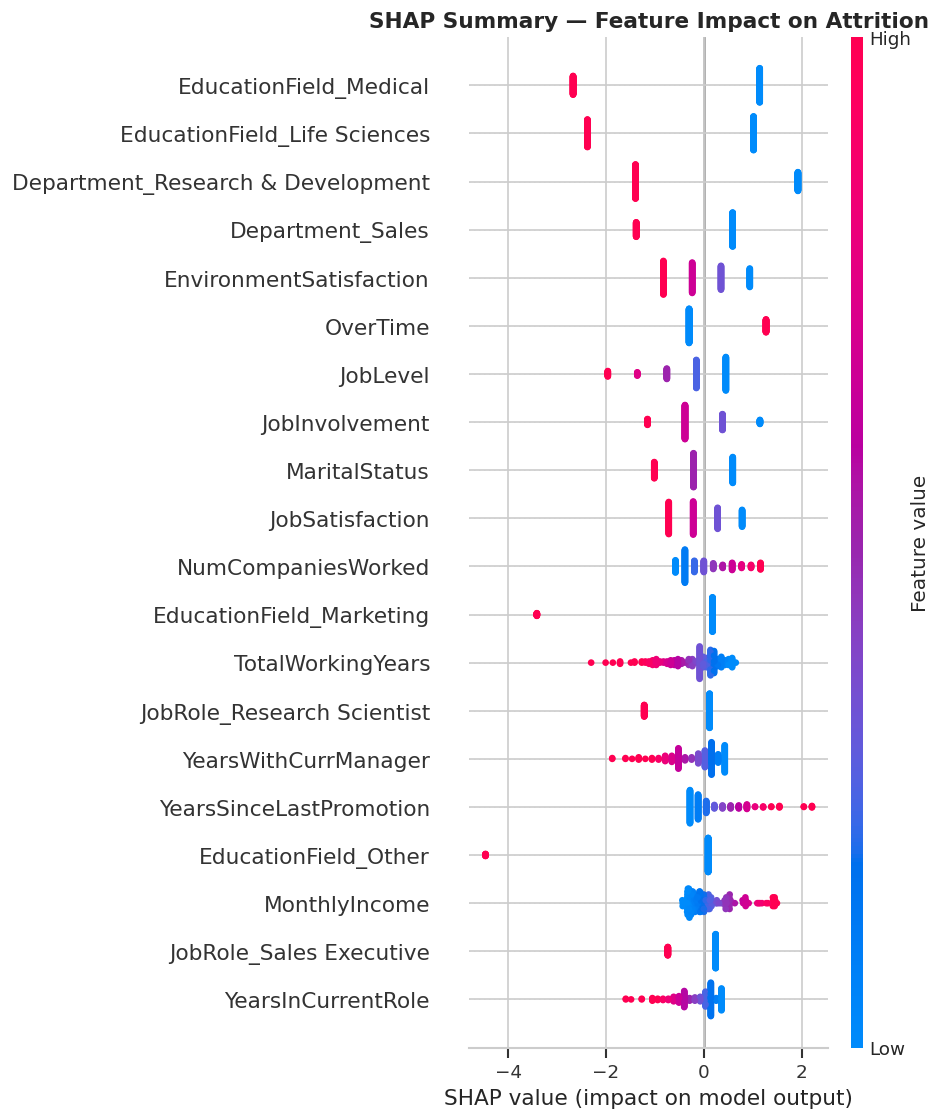


💡 Red = increases attrition risk | Blue = decreases attrition risk


In [24]:
# ── 9.2 SHAP Values for Global Explainability ─────────
print('Computing SHAP values (this may take ~30 seconds)...')

# Use a sample for speed (200 samples from X_test_scaled for explanation)
X_sample = pd.DataFrame(X_test_scaled[:200], columns=X.columns)

explainer = None
sv = None

# Determine the appropriate SHAP explainer based on the best_model type
if isinstance(best_model, (RandomForestClassifier, GradientBoostingClassifier, XGBClassifier)):
    explainer = shap.TreeExplainer(best_model)
    # For binary classification, shap_values is often a list of arrays (one per class).
    # We are interested in the shap_values for the positive class (class 1).
    shap_values = explainer.shap_values(X_sample)
    if isinstance(shap_values, list):
        sv = shap_values[1] # For TreeExplainer, often shap_values[1] is for the positive class
    else:
        sv = shap_values

elif isinstance(best_model, LogisticRegression):
    # For LinearExplainer, pass the model and a background dataset
    # Using a subset of the scaled training data as background
    X_background_sample = X_train_scaled[np.random.choice(X_train_scaled.shape[0], min(X_train_scaled.shape[0], 100), replace=False)]
    explainer = shap.LinearExplainer(best_model, X_background_sample)
    shap_values = explainer.shap_values(X_sample)
    sv = shap_values # LinearExplainer directly returns values for the positive class

else:
    print(f"Warning: SHAP explainer not implemented for model type {type(best_model)}. Skipping SHAP explanation.")
    # Assign dummy values to avoid errors in subsequent plotting if explainer couldn't be created
    sv = np.zeros_like(X_sample)


# Check if SHAP values were successfully computed before plotting
if explainer is not None and sv is not None and not np.all(sv == 0):
    # Summary Plot (Bar)
    plt.figure(figsize=(10, 7))
    shap.summary_plot(sv, X_sample, plot_type='bar', show=False)
    plt.title('SHAP Feature Importance — Global', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Beeswarm plot
    plt.figure(figsize=(10, 7))
    shap.summary_plot(sv, X_sample, show=False)
    plt.title('SHAP Summary — Feature Impact on Attrition', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print('\n💡 Red = increases attrition risk | Blue = decreases attrition risk')
else:
    print("\n💡 SHAP explanation plots could not be generated for this model type or due to an error.")


🔍 Explaining prediction for employee index 0:


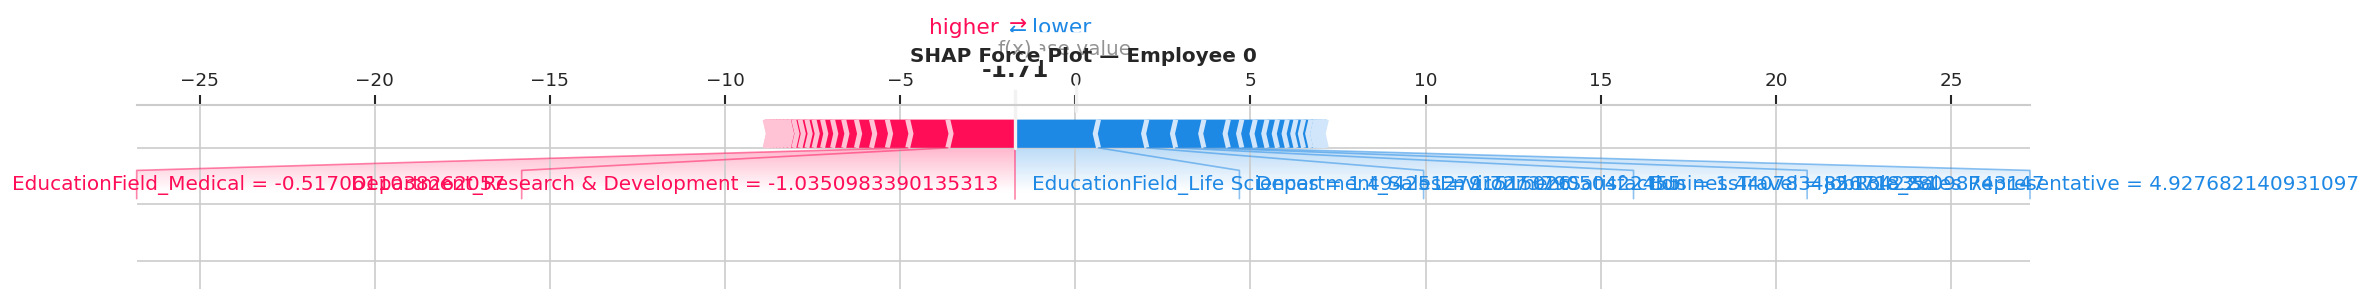

In [25]:
# ── 9.3 SHAP Individual Employee Explanation ──────────
# Explain WHY a specific high-risk employee is flagged
employee_to_explain = 0  # Change this index to explore different employees

print(f'🔍 Explaining prediction for employee index {employee_to_explain}:')
shap.initjs()

force_plot = shap.force_plot(
    explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
    sv[employee_to_explain],
    X_sample.iloc[employee_to_explain],
    matplotlib=True,
    show=False
)
plt.title(f'SHAP Force Plot — Employee {employee_to_explain}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:
# ── 9.4 Auto-Generate Reason Codes ────────────────────
def generate_reason_codes(employee_index, top_n=3):
    """
    Generate human-readable risk reason codes for an employee.
    """
    emp = df.iloc[employee_index]
    prob = all_probs[employee_index]
    risk = get_risk_category(prob)

    reasons = []
    if emp['OverTime'] == 'Yes':            reasons.append('⚠️  Working overtime')
    if emp['JobSatisfaction'] <= 2:         reasons.append('😞 Low job satisfaction')
    if emp['EnvironmentSatisfaction'] <= 2: reasons.append('🏢 Low environment satisfaction')
    if emp['WorkLifeBalance'] <= 2:         reasons.append('⚖️  Poor work-life balance')
    if emp['YearsSinceLastPromotion'] >= 4: reasons.append(f'📉 No promotion in {int(emp["YearsSinceLastPromotion"])} years')
    if emp['MonthlyIncome'] < 3000:         reasons.append(f'💰 Low monthly income (${int(emp["MonthlyIncome"]):,})')
    if emp['NumCompaniesWorked'] >= 5:      reasons.append(f'🔄 High job hopping ({int(emp["NumCompaniesWorked"])} companies)')
    if emp['BusinessTravel'] == 'Travel_Frequently': reasons.append('✈️  Frequent business travel')
    if emp['MaritalStatus'] == 'Single':    reasons.append('👤 Single marital status')
    if emp['StockOptionLevel'] == 0:        reasons.append('📊 No stock options')

    print(f'Employee {employee_index} | Attrition Prob: {prob*100:.1f}% | {risk}')
    if reasons:
        print('Risk Factors:')
        for r in reasons[:top_n]:
            print(f'   {r}')
    else:
        print('  ✅ No major risk factors detected')

# Show reason codes for top 5 highest-risk employees
print('='*60)
print('TOP 5 HIGHEST RISK EMPLOYEES — REASON CODES')
print('='*60)
top5_risky = np.argsort(all_probs)[-5:][::-1]
for idx in top5_risky:
    generate_reason_codes(idx)
    print()

TOP 5 HIGHEST RISK EMPLOYEES — REASON CODES
Employee 463 | Attrition Prob: 99.0% | 🔴 High Risk
Risk Factors:
   ⚠️  Working overtime
   ⚖️  Poor work-life balance
   💰 Low monthly income ($2,340)

Employee 357 | Attrition Prob: 98.8% | 🔴 High Risk
Risk Factors:
   ⚠️  Working overtime
   😞 Low job satisfaction
   🏢 Low environment satisfaction

Employee 1057 | Attrition Prob: 98.2% | 🔴 High Risk
Risk Factors:
   😞 Low job satisfaction
   🏢 Low environment satisfaction
   ⚖️  Poor work-life balance

Employee 1060 | Attrition Prob: 98.1% | 🔴 High Risk
Risk Factors:
   ⚠️  Working overtime
   😞 Low job satisfaction
   🏢 Low environment satisfaction

Employee 1379 | Attrition Prob: 98.0% | 🔴 High Risk
Risk Factors:
   😞 Low job satisfaction
   🏢 Low environment satisfaction
   💰 Low monthly income ($2,863)



## 💾 CELL 10 — Export Results

In [27]:
# ── 10.1 Save Risk Scores to CSV ──────────────────────
full_risk_df = df.copy()
full_risk_df['Employee_ID']    = [f'EMP_{str(i+1001).zfill(4)}' for i in range(len(df))]
full_risk_df['Attrition_Prob'] = (all_probs * 100).round(2)
full_risk_df['Risk_Category']  = [get_risk_category(p) for p in all_probs]

# Save to CSV
output_file = 'Employee_Attrition_Risk_Scores.csv'
full_risk_df.to_csv(output_file, index=False)

# Auto-download
from google.colab import files
files.download(output_file)

print(f'✅ Exported {len(full_risk_df)} employee records with risk scores!')
print(f'\nRisk Summary:')
print(full_risk_df['Risk_Category'].value_counts())

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Exported 1470 employee records with risk scores!

Risk Summary:
Risk_Category
🟢 Low Risk       1112
🟡 Medium Risk     211
🔴 High Risk       147
Name: count, dtype: int64


In [28]:
# ── 10.2 Save Trained Model with Pickle ───────────────
import pickle

model_bundle = {
    'model':      best_model,
    'scaler':     scaler,
    'features':   X.columns.tolist(),
    'model_name': best_model_name
}

with open('attrition_model.pkl', 'wb') as f:
    pickle.dump(model_bundle, f)

files.download('attrition_model.pkl')
print(f'✅ Model saved: attrition_model.pkl')
print(f'Model: {best_model_name}')
print(f'Features: {len(X.columns)}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Model saved: attrition_model.pkl
Model: Logistic Regression
Features: 42


In [29]:
# ── 10.3 Final Project Summary ────────────────────────
print('='*65)
print(' 🎉 PROJECT COMPLETE — FINAL SUMMARY')
print('='*65)
print(f'  Dataset          : {len(df)} employees, {len(df.columns)} features')
print(f'  Attrition Rate   : {df["Attrition"].mean()*100:.1f}%')
print(f'  Best Model       : {best_model_name}')
best_results = results[best_model_name]
print(f'  Accuracy         : {best_results["Accuracy"]*100:.1f}%')
print(f'  Recall           : {best_results["Recall"]*100:.1f}% (attrition detection)')
print(f'  ROC-AUC          : {best_results["ROC-AUC"]:.4f}')
print(f'  F1-Score         : {best_results["F1-Score"]:.4f}')
print('-'*65)
rc = full_risk_df['Risk_Category'].value_counts()
print(f'  🔴 High Risk     : {rc.get("🔴 High Risk", 0)} employees')
print(f'  🟡 Medium Risk   : {rc.get("🟡 Medium Risk", 0)} employees')
print(f'  🟢 Low Risk      : {rc.get("🟢 Low Risk", 0)} employees')
print('='*65)
print('  ✅ Outputs saved: Risk CSV + Trained Model (.pkl)')
print('='*65)

 🎉 PROJECT COMPLETE — FINAL SUMMARY
  Dataset          : 1470 employees, 31 features
  Attrition Rate   : 16.1%
  Best Model       : Logistic Regression
  Accuracy         : 84.0%
  Recall           : 44.7% (attrition detection)
  ROC-AUC          : 0.7725
  F1-Score         : 0.4719
-----------------------------------------------------------------
  🔴 High Risk     : 147 employees
  🟡 Medium Risk   : 211 employees
  🟢 Low Risk      : 1112 employees
  ✅ Outputs saved: Risk CSV + Trained Model (.pkl)
